# Graph Neural Networks for Molecular Solubility Prediction on ESOL

This notebook compares three graph neural network architectures on the MoleculeNet ESOL dataset:

- **GINEConv**
- **AttentiveFP**
- **NNConv**

The goal is to predict the aqueous solubility of a molecule from its graph representation.

Each molecule is treated as a graph:

- atoms are nodes,
- chemical bonds are edges,
- atom descriptors are node features,
- bond descriptors are edge attributes,
- the ESOL value is a graph-level regression target.

The notebook is organized as a clean end-to-end workflow:

1. environment setup,
2. dataset loading and inspection,
3. molecule visualization,
4. reproducible data split,
5. architecture definitions,
6. shared training/evaluation utilities,
7. model comparison,
8. diagnostic plots,
9. interpretation of results.

## 1. Check the PyTorch and CUDA environment

Before working with PyTorch Geometric, it is useful to verify the installed PyTorch version, the CUDA version used by PyTorch, and whether a GPU is available.

This cell does not train anything. It only confirms the computational environment. If `CUDA available` is `True`, the later training cell can use the GPU; otherwise, the notebook will still run on CPU.

In [1]:
import torch

# Check current PyTorch and CUDA version
print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.11.0+cu128
Torch CUDA version: 12.8
CUDA available: True


## 2. Install PyTorch Geometric

This cell installs `torch_geometric` and its optional CUDA-compatible extensions.

PyTorch Geometric is the main library used in this notebook. It provides graph data structures, molecular graph datasets, graph mini-batching, and message-passing layers such as `GINEConv`, `NNConv`, and `AttentiveFP`.

> Note: the wheel URL is CUDA/PyTorch-version specific. If this cell fails in a different Colab/runtime environment, the URL may need to be adjusted to match the currently installed PyTorch and CUDA versions printed in the previous cell.

In [2]:
# Install PyTorch Geometric and CUDA-compatible optional extensions
!pip install -q torch_geometric
!pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.11.0+cu128.html

## 3. Install RDKit

`RDKit` is a cheminformatics library. In this notebook, it is used mainly to convert a SMILES string into a molecule object and visualize the molecule.

The GNN models themselves do not directly use the RDKit object. They train on the graph representation already provided by the PyTorch Geometric `MoleculeNet` dataset.

In [3]:
!pip install rdkit

## 4. Load the MoleculeNet ESOL dataset

The ESOL dataset is loaded through `torch_geometric.datasets.MoleculeNet`.

Each molecule is represented as a graph:

- **Nodes** correspond to atoms.
- **Edges** correspond to chemical bonds.
- `x` stores atom/node features.
- `edge_index` stores graph connectivity.
- `edge_attr` stores bond/edge features.
- `y` is the graph-level target: the measured aqueous solubility value.

Because ESOL is a molecular-property prediction dataset, this notebook is a **graph-level regression** task: one scalar prediction is produced for each whole molecule.

In [4]:
import torch
import rdkit
from torch_geometric.datasets import MoleculeNet

# Load the ESOL dataset
data = MoleculeNet(root="./data", name="ESOL")

## 5. Inspect the dataset object

This cell prints the basic structure of the ESOL dataset.

The most important quantities are:

- `num_node_features`: the length of each atom feature vector.
- `num_edge_features`: the length of each bond feature vector.
- `len(data)`: the number of molecular graphs.
- `data[0].y`: the target solubility value for one molecule.

For ESOL, the target is continuous, so we use regression metrics such as MSE, RMSE, MAE, and $R^2$, not classification accuracy.

In [5]:
# Investigating the dataset

print("Dataset type:", type(data))
print("Dataset:", data)

# For molecular graphs
print("Number of node features:", data.num_node_features)
print("Number of edge features:", data.num_edge_features)

# ESOL is regression, so do not use data.num_classes
print("Target shape for one sample:", data[0].y.shape)
print("Target value for one sample:", data[0].y.item())

# Dataset size
print("Dataset length:", len(data))

Dataset type: <class 'torch_geometric.datasets.molecule_net.MoleculeNet'>
Dataset: ESOL(1128)
Number of node features: 9
Number of edge features: 3
Target shape for one sample: torch.Size([1, 1])
Target value for one sample: -0.7699999809265137
Dataset length: 1128


## 6. Inspect one molecular graph

A single PyG graph object stores all information needed by the GNN.

For one molecule:

- `sample.x` has shape `[num_atoms, num_node_features]`.
- `sample.edge_index` has shape `[2, num_directed_edges]`.
- `sample.edge_attr` has shape `[num_directed_edges, num_edge_features]`.
- `sample.y` contains the graph-level ESOL target.
- `sample.smiles` stores the original SMILES string.

PyG usually stores molecular bonds as **directed edges in both directions**, so one chemical bond can appear as two directed graph edges.

In [6]:
# One graph sample
sample = data[0]
print("\nDataset sample:")
print(sample)

print("\nSample nodes:", sample.num_nodes)
print("Sample directed edges:", sample.num_edges)
print("Sample node feature matrix shape:", sample.x.shape)
print("Sample edge index shape:", sample.edge_index.shape)
print("Sample edge attribute shape:", sample.edge_attr.shape)
print("Sample target shape:", sample.y.shape)
print("Sample SMILES:", sample.smiles)


Dataset sample:
Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])

Sample nodes: 32
Sample directed edges: 68
Sample node feature matrix shape: torch.Size([32, 9])
Sample edge index shape: torch.Size([2, 68])
Sample edge attribute shape: torch.Size([68, 3])
Sample target shape: torch.Size([1, 1])
Sample SMILES: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 


## 7. Look at the atom feature matrix

This cell displays the node feature matrix for the first molecule.

Each row represents one atom. Each column is a numerical or encoded atom descriptor provided by the dataset preprocessing pipeline, such as atom type, atom degree, aromaticity-related information, or other molecular descriptors depending on the PyG MoleculeNet featurization.

The GNN does not read atom names directly. It learns from these numerical node feature vectors.

In [7]:
# Investigating the features
# Shape: [num_nodes, num_node_features]
data[0].x

tensor([[8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 0],
        [6, 0, 2, 5, 0, 0, 2, 0, 0],
        [7, 0, 1, 5, 0, 0, 2, 0, 0],
        [6, 0, 3, 5, 0, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
 

## 8. Look at the edge list in COO format

`edge_index` is the sparse connectivity representation used by PyTorch Geometric.

Each column of `edge_index` is one directed edge:

$$
\text{edge_index}_{(:,k)}
=
\begin{bmatrix}
\text{source node} \\
\text{target node}
\end{bmatrix}
$$

During message passing, node embeddings are sent along these edges. The matching row `edge_attr[k]` contains the bond features for the same directed edge.

In [8]:
# Investigating the edges in sparse COO format
# Shape [2, num_edges]
data[0].edge_index.t()

tensor([[ 0,  1],
        [ 1,  0],
        [ 1,  2],
        [ 2,  1],
        [ 2,  3],
        [ 2, 30],
        [ 3,  2],
        [ 3,  4],
        [ 4,  3],
        [ 4,  5],
        [ 4, 26],
        [ 5,  4],
        [ 5,  6],
        [ 6,  5],
        [ 6,  7],
        [ 7,  6],
        [ 7,  8],
        [ 7, 24],
        [ 8,  7],
        [ 8,  9],
        [ 9,  8],
        [ 9, 10],
        [ 9, 20],
        [10,  9],
        [10, 11],
        [11, 10],
        [11, 12],
        [11, 14],
        [12, 11],
        [12, 13],
        [13, 12],
        [14, 11],
        [14, 15],
        [14, 19],
        [15, 14],
        [15, 16],
        [16, 15],
        [16, 17],
        [17, 16],
        [17, 18],
        [18, 17],
        [18, 19],
        [19, 14],
        [19, 18],
        [20,  9],
        [20, 21],
        [20, 22],
        [21, 20],
        [22, 20],
        [22, 23],
        [22, 24],
        [23, 22],
        [24,  7],
        [24, 22],
        [24, 25],
        [2

## 9. Read the SMILES representation

A SMILES string is a compact text representation of a molecule.

Here we inspect the SMILES string for the first molecule in the dataset. This is useful because the PyG molecular graph was originally constructed from molecular information such as this.

In [9]:
data[0]["smiles"]

'OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O '

## 10. Convert SMILES to an RDKit molecule

This cell converts the SMILES string into an RDKit molecule object and displays it.

This visualization helps connect the abstract graph representation to the actual chemical structure. Conceptually:

- atoms in the RDKit drawing correspond to graph nodes,
- bonds in the RDKit drawing correspond to graph edges,
- atom and bond properties become `x` and `edge_attr` in the PyG graph.

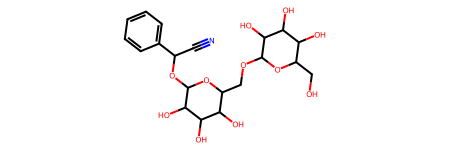

In [10]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
molecule = Chem.MolFromSmiles(data[0]["smiles"])
molecule

## 11. Confirm the RDKit object type

This quick check confirms that the SMILES string has been converted into an RDKit molecule object.

Again, this object is only used for visualization and interpretation here. The model training uses the already prepared PyG graph tensors.

In [11]:
type(molecule)

rdkit.Chem.rdchem.Mol

## 12. Create a reproducible train/validation/test split

This cell prepares the data split and the PyG `DataLoader` objects.

The split is deterministic:

- 60% of molecules are used for training,
- 20% for validation,
- 20% for testing.

The same random seed is used for every model. This is important because the goal is to compare **architectures**, not different random splits.

The PyG `DataLoader` batches multiple molecular graphs into one large disconnected graph. The `batch` vector tells PyG which nodes belong to which original molecule, allowing graph-level pooling later.

In [12]:
# --------------------------------------------------
# Reproducible split and DataLoaders
# --------------------------------------------------
import random
import numpy as np
import torch
from torch_geometric.loader import DataLoader

SEED = 42
BATCH_SIZE = 32

def seed_everything(seed=SEED):
    """Seed Python, NumPy, PyTorch CPU, and PyTorch CUDA for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These two lines improve reproducibility on CUDA.
    # They may make training slightly slower, but ESOL is small.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

# Deterministic 60/20/20 split.
# Using an explicit torch.Generator avoids relying on hidden global RNG state.
split_generator = torch.Generator().manual_seed(SEED)
permutation = torch.randperm(len(data), generator=split_generator).tolist()

dataset = data.index_select(permutation)

n_total = len(dataset)
n_train = int(0.60 * n_total)
n_val = int(0.20 * n_total)
n_test = n_total - n_train - n_val

train_dataset = dataset[:n_train]
val_dataset = dataset[n_train:n_train + n_val]
test_dataset = dataset[n_train + n_val:]


def make_data_loaders(seed=SEED):
    """Create fresh loaders for one model run.

    The train loader gets its own generator so every architecture sees the
    same shuffled mini-batch order when trained from the same seed.
    """
    train_generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_loader, val_loader, test_loader


# Default loaders, useful for quick inspection and plotting later.
train_loader, val_loader, test_loader = make_data_loaders(SEED)

print("Total molecules:", n_total)
print("Train molecules:", len(train_dataset))
print("Validation molecules:", len(val_dataset))
print("Test molecules:", len(test_dataset))
print("Node features:", dataset.num_node_features)
print("Edge features:", dataset.num_edge_features)


Total molecules: 1128
Train molecules: 676
Validation molecules: 225
Test molecules: 227
Node features: 9
Edge features: 3


## 13. Define the three GNN architectures

This cell defines the three architectures compared in the notebook:

1. `GINE_ESOL`
2. `AttentiveFP_ESOL`
3. `NNConv_ESOL`

All three models solve the same task: graph-level regression for ESOL.

### General message-passing idea

A molecular GNN updates each atom embedding by collecting information from neighboring atoms and bonds. A generic message-passing layer can be written as

$$
h_i^{(\ell+1)}
=
\phi^{(\ell)}
\left(
h_i^{(\ell)},
\operatorname{AGG}_{j \in \mathcal{N}(i)}
\psi^{(\ell)}
\left(h_i^{(\ell)}, h_j^{(\ell)}, e_{j i}\right)
\right),
$$

where:

- $(h_i^{(\ell)})$ is the embedding of atom $(i)$ at layer $(\ell)$,
- $(h_j^{(\ell)})$ is the embedding of a neighboring atom,
- $(e_{ji})$ is the edge/bond feature vector,
- $(\psi)$ builds messages,
- `AGG` combines neighbor messages,
- $(\phi)$ updates the node embedding.

After message passing, node embeddings are pooled into one graph embedding. This notebook uses both global max pooling and global mean pooling for `GINEConv` and `NNConv`.

---

### 13.1 GINEConv model

`GINEConv` is an edge-aware extension of GIN. It is useful for molecular graphs because bond features can directly influence the messages passed between atoms.

A simplified GINE update is

$$
h_i^{(\ell+1)}
=
\operatorname{MLP}
\left(
(1+\epsilon)h_i^{(\ell)}
+
\sum_{j \in \mathcal{N}(i)}
\operatorname{ReLU}
\left(
h_j^{(\ell)} + e_{ji}
\right)
\right).
$$

In this implementation:

- node features are first projected to `hidden_channels`,
- each `GINEConv` layer receives `edge_attr`,
- the internal MLP learns how to transform aggregated neighbor information,
- two GINE layers allow information to propagate across two-hop neighborhoods,
- mean and max graph pooling produce a graph embedding,
- a final MLP predicts one ESOL value.

So, `GINEConv` uses edge attributes directly inside the message-passing update.

---

### 13.2 AttentiveFP model

`AttentiveFP` is a molecular GNN architecture designed for chemical property prediction.

Its key idea is attention-based message passing: instead of treating all neighboring atoms equally, the model learns attention weights so that more relevant neighboring atoms contribute more strongly to the updated atom representation.

In PyG's built-in `AttentiveFP` implementation:

- `edge_attr` is passed through `edge_dim`,
- bond information is used in the initial edge-aware graph attention stage,
- later atom-level refinement uses attention and recurrent-style updates,
- graph-level readout is also attention-based over multiple timesteps.

This makes AttentiveFP different from GINE and NNConv: it does not only aggregate messages with a fixed sum or mean rule; it learns attention-based importance weights.

---

### 13.3 NNConv model

`NNConv` is an edge-conditioned convolution.

The main idea is that every bond can generate its own message transformation matrix. For an edge $(j \rightarrow i)$, the edge feature $(e_{ji})$ is passed through a small neural network:

$$
W_{ji} = f_\theta(e_{ji}).
$$

Then the neighbor message is approximately

$$
m_{ji} = W_{ji} h_j.
$$

So, instead of simply adding edge features to node features, `NNConv` uses edge attributes to create edge-specific filters.

In this implementation:

- a node encoder maps atom features to hidden size,
- an edge network maps each bond feature vector into a `hidden_channels × hidden_channels` matrix,
- two NNConv layers perform edge-conditioned message passing,
- batch normalization stabilizes training,
- mean and max graph pooling produce the final graph representation,
- an MLP predicts the ESOL value.

Because NNConv creates many edge-conditioned weights, it can be expressive but may overfit on small datasets such as ESOL. That is why the hidden size is kept modest here.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout

from torch_geometric.nn import GINEConv, NNConv
from torch_geometric.nn import global_mean_pool as gap
from torch_geometric.nn import global_max_pool as gmp
from torch_geometric.nn.models import AttentiveFP


class GINE_ESOL(torch.nn.Module):
    """Small edge-aware GINE model for ESOL.

    Uses edge_attr in every GINEConv layer.
    """
    def __init__(self, num_node_features, num_edge_features, hidden_channels=32, dropout=0.3):
        super().__init__()

        self.node_encoder = Linear(num_node_features, hidden_channels)
        self.dropout = Dropout(dropout)

        def make_mlp():
            return Sequential(
                Linear(hidden_channels, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU(),
                Dropout(dropout),
                Linear(hidden_channels, hidden_channels)
            )

        self.conv1 = GINEConv(make_mlp(), edge_dim=num_edge_features)
        self.conv2 = GINEConv(make_mlp(), edge_dim=num_edge_features)

        self.out = Sequential(
            Linear(hidden_channels * 2, hidden_channels),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch_index):
        x = self.node_encoder(x.float())
        edge_attr = edge_attr.float()

        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        graph_embedding = torch.cat([
            gmp(x, batch_index),
            gap(x, batch_index)
        ], dim=1)

        return self.out(graph_embedding)


class AttentiveFP_ESOL(torch.nn.Module):
    """PyG AttentiveFP model for ESOL.

    PyG AttentiveFP accepts edge_attr and uses edge_dim.
    Note: in the built-in PyG implementation, edge_attr is used in the initial
    edge-aware GATEConv stage; later atom-level layers are attention layers.
    """
    def __init__(
        self,
        num_node_features,
        num_edge_features,
        hidden_channels=64,
        num_layers=2,
        num_timesteps=2,
        dropout=0.3
    ):
        super().__init__()

        self.model = AttentiveFP(
            in_channels=num_node_features,
            hidden_channels=hidden_channels,
            out_channels=1,
            edge_dim=num_edge_features,
            num_layers=num_layers,
            num_timesteps=num_timesteps,
            dropout=dropout
        )

    def forward(self, x, edge_index, edge_attr, batch_index):
        return self.model(
            x.float(),
            edge_index,
            edge_attr.float(),
            batch_index
        )


class NNConv_ESOL(torch.nn.Module):
    """Small edge-conditioned NNConv model for ESOL.

    Uses edge_attr to generate edge-specific message transformation weights.
    Kept small because ESOL is a small dataset and NNConv can overfit quickly.
    """
    def __init__(self, num_node_features, num_edge_features, hidden_channels=32, dropout=0.3):
        super().__init__()

        self.node_encoder = Linear(num_node_features, hidden_channels)
        self.dropout = Dropout(dropout)

        def make_edge_network():
            # Maps each edge feature vector into a hidden_channels x hidden_channels matrix.
            return Sequential(
                Linear(num_edge_features, hidden_channels),
                ReLU(),
                Linear(hidden_channels, hidden_channels * hidden_channels)
            )

        self.conv1 = NNConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            nn=make_edge_network(),
            aggr="mean"
        )

        self.conv2 = NNConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            nn=make_edge_network(),
            aggr="mean"
        )

        self.bn1 = BatchNorm1d(hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.out = Sequential(
            Linear(hidden_channels * 2, hidden_channels),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch_index):
        x = self.node_encoder(x.float())
        edge_attr = edge_attr.float()

        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        graph_embedding = torch.cat([
            gmp(x, batch_index),
            gap(x, batch_index)
        ], dim=1)

        return self.out(graph_embedding)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 14. Define shared training, evaluation, and scheduler utilities

This cell defines helper functions used by all three architectures.

The purpose is to make the comparison fair:

- all models use the same loss function: mean squared error,
- all models are evaluated with the same metrics,
- all models use the same optimizer type: AdamW,
- all models can use the same learning-rate scheduler,
- all models use early stopping based on validation loss.

### What happens in training?

For each mini-batch of molecular graphs:

1. the batch is moved to CPU or GPU,
2. the model receives `x`, `edge_index`, `edge_attr`, and `batch`,
3. the model predicts one scalar per molecule,
4. MSE loss is computed against `batch.y`,
5. gradients are backpropagated,
6. AdamW updates the parameters.

### Why use validation loss?

The validation set is not used to update weights. It is used to decide which epoch gives the best generalization. The best model state is saved and restored before evaluating on the test set.

In [14]:
import copy
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    y_true = []
    y_pred = []

    for batch in loader:
        batch = batch.to(device)

        pred = model(
            batch.x.float(),
            batch.edge_index,
            batch.edge_attr.float(),
            batch.batch
        )

        y_true.extend(batch.y.detach().cpu().numpy().reshape(-1))
        y_pred.extend(pred.detach().cpu().numpy().reshape(-1))

    return np.array(y_true), np.array(y_pred)


def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_graphs = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred = model(
                batch.x.float(),
                batch.edge_index,
                batch.edge_attr.float(),
                batch.batch
            )

            target = batch.y.float().view_as(pred)
            loss = loss_fn(pred, target)

            total_loss += loss.item() * batch.num_graphs
            total_graphs += batch.num_graphs

    return total_loss / total_graphs


def build_scheduler(
    optimizer,
    scheduler_type="cosine",
    epochs=1000,
    eta_min=1e-5,
    cosine_t_max=None,
    plateau_factor=0.5,
    plateau_patience=30
):
    """Return an LR scheduler.

    scheduler_type options:
    - "cosine": CosineAnnealingLR stepped once per epoch.
    - "plateau": ReduceLROnPlateau stepped using validation loss.
    - None / "none": no LR scheduler.
    """
    if scheduler_type is None or scheduler_type == "none":
        return None

    if scheduler_type == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_t_max or epochs,
            eta_min=eta_min
        )

    if scheduler_type == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=plateau_factor,
            patience=plateau_patience
        )

    raise ValueError(
        "scheduler_type must be one of: 'cosine', 'plateau', 'none', or None"
    )


def train_one_model(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=1000,
    patience=100,
    lr=0.001,
    weight_decay=1e-4,
    scheduler_type="cosine",
    eta_min=1e-5,
    cosine_t_max=None,
    print_every=50
):
    model = model.to(device)

    loss_fn = nn.MSELoss()

    # Important: create optimizer after moving model to device.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = build_scheduler(
        optimizer,
        scheduler_type=scheduler_type,
        epochs=epochs,
        eta_min=eta_min,
        cosine_t_max=cosine_t_max
    )

    train_losses = []
    val_losses = []
    lr_history = []

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0
    patience_counter = 0

    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)
    print(model)
    print("Parameters:", count_parameters(model))
    print("Model device:", next(model.parameters()).device)
    print("Scheduler:", scheduler_type)

    for epoch in range(epochs):
        model.train()

        # LR used during this epoch.
        current_lr = optimizer.param_groups[0]["lr"]
        lr_history.append(current_lr)

        total_loss = 0.0
        total_graphs = 0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()

            pred = model(
                batch.x.float(),
                batch.edge_index,
                batch.edge_attr.float(),
                batch.batch
            )

            target = batch.y.float().view_as(pred)
            loss = loss_fn(pred, target)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            total_graphs += batch.num_graphs

        train_loss = total_loss / total_graphs
        val_loss = evaluate_loss(model, val_loader, loss_fn, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Step the scheduler after the validation loss has been computed.
        if scheduler is not None:
            if scheduler_type == "plateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:04d} | "
                f"Train MSE: {train_loss:.4f} | "
                f"Val MSE: {val_loss:.4f} | "
                f"Best Val MSE: {best_val_loss:.4f} | "
                f"LR: {current_lr:.6f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    y_true_test, y_pred_test = predict_model(model, test_loader, device)
    test_metrics = compute_metrics(y_true_test, y_pred_test)

    result = {
        "model_name": model_name,
        "model": model,
        "parameters": count_parameters(model),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lr_history": lr_history,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch,
        "trained_epochs": len(train_losses),
        "test_metrics": test_metrics,
        "y_true_test": y_true_test,
        "y_pred_test": y_pred_test
    }

    print(
        f"Finished {model_name} | "
        f"Best Val MSE: {best_val_loss:.4f} | "
        f"Test RMSE: {test_metrics['RMSE']:.4f} | "
        f"Test R2: {test_metrics['R2']:.4f}"
    )

    return result


Using device: cuda


## 15. Train all three architectures under the same protocol

This cell creates and trains the three models sequentially.

The important fairness choices are:

- the same train/validation/test split,
- the same random seed,
- the same batch size,
- the same optimizer family,
- the same learning-rate scheduler,
- the same early-stopping patience,
- the same evaluation metrics.

The model factory dictionary makes the comparison clean: each entry defines how to create one architecture. The training loop then applies the same `train_one_model` function to every model.

The results are stored in `comparison_results`, including:

- the trained model,
- loss histories,
- learning-rate history,
- best validation MSE,
- test metrics,
- predictions on the test set.

In [15]:
# --------------------------------------------------
# Create and train all models
# --------------------------------------------------

EPOCHS = 1000
PATIENCE = 100
BASE_LR = 0.001
WEIGHT_DECAY = 1e-4

# Cosine annealing settings.
# T_max=EPOCHS means one smooth decay from BASE_LR to ETA_MIN across training.
# You can set COSINE_T_MAX=100 or 200 for a faster decay cycle.
SCHEDULER_TYPE = "cosine"
ETA_MIN = 1e-5
COSINE_T_MAX = EPOCHS

model_factories = {
    "GINEConv": lambda: GINE_ESOL(
        num_node_features=dataset.num_node_features,
        num_edge_features=dataset.num_edge_features,
        hidden_channels=32,
        dropout=0.3
    ),
    "AttentiveFP": lambda: AttentiveFP_ESOL(
        num_node_features=dataset.num_node_features,
        num_edge_features=dataset.num_edge_features,
        hidden_channels=32,
        num_layers=2,
        num_timesteps=2,
        dropout=0.3
    ),
    "NNConv": lambda: NNConv_ESOL(
        num_node_features=dataset.num_node_features,
        num_edge_features=dataset.num_edge_features,
        hidden_channels=32,
        dropout=0.3
    )
}

comparison_results = {}

for model_name, factory in model_factories.items():
    # Reset seed and recreate loaders so each architecture uses the same
    # data split and the same mini-batch shuffle order.
    seed_everything(SEED)
    train_loader, val_loader, test_loader = make_data_loaders(SEED)

    model = factory()

    result = train_one_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        epochs=EPOCHS,
        patience=PATIENCE,
        lr=BASE_LR,
        weight_decay=WEIGHT_DECAY,
        scheduler_type=SCHEDULER_TYPE,
        eta_min=ETA_MIN,
        cosine_t_max=COSINE_T_MAX,
        print_every=50
    )

    comparison_results[model_name] = result



Training GINEConv
GINE_ESOL(
  (node_encoder): Linear(in_features=9, out_features=32, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=32, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=32, bias=True)
  ))
  (out): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parameters: 7041
Model device: cuda:0
Scheduler: c

## 16. Build the architecture comparison table

This cell summarizes the final performance of all models.

The table includes:

- number of trainable parameters,
- best validation epoch,
- number of trained epochs,
- best validation MSE,
- test MSE,
- test RMSE,
- test MAE,
- test $(R^2)$.

The model with the lowest test RMSE is selected as the best model for this particular split and training run.

A lower RMSE means the predicted solubility values are, on average, closer to the true ESOL targets.

In [16]:
# --------------------------------------------------
# Build comparison summary table
# --------------------------------------------------

summary_rows = []

for model_name, result in comparison_results.items():
    metrics = result["test_metrics"]

    summary_rows.append({
        "Model": model_name,
        "Parameters": result["parameters"],
        "Best Epoch": result["best_epoch"],
        "Trained Epochs": result["trained_epochs"],
        "Best Val MSE": result["best_val_mse"],
        "Test MSE": metrics["MSE"],
        "Test RMSE": metrics["RMSE"],
        "Test MAE": metrics["MAE"],
        "Test R2": metrics["R2"]
    })

comparison_df = pd.DataFrame(summary_rows)
comparison_df = comparison_df.sort_values("Test RMSE").reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
best_result = comparison_results[best_model_name]
best_model = best_result["model"]

print("Best model by Test RMSE:", best_model_name)


,Model,Parameters,Best Epoch,Trained Epochs,Best Val MSE,Test MSE,Test RMSE,Test MAE,Test R2
0,AttentiveFP,23841,478,579,0.405394,0.378955,0.615593,0.450703,0.919660
1,NNConv,72513,22,123,2.883652,2.861151,1.691494,1.329667,0.393428
2,GINEConv,7041,1,102,3.498603,4.135173,2.033513,1.555737,0.123331


Best model by Test RMSE: AttentiveFP


## 17. Plot training and validation loss curves

This cell creates one clean loss plot per model.

Each plot shows:

- training MSE loss,
- validation MSE loss,
- the best validation MSE,
- the epoch where the best validation MSE occurred.

These curves are useful for diagnosing learning behavior:

- if both losses are high, the model may be underfitting,
- if training loss decreases but validation loss increases, the model may be overfitting,
- if validation loss plateaus, early stopping prevents unnecessary training.

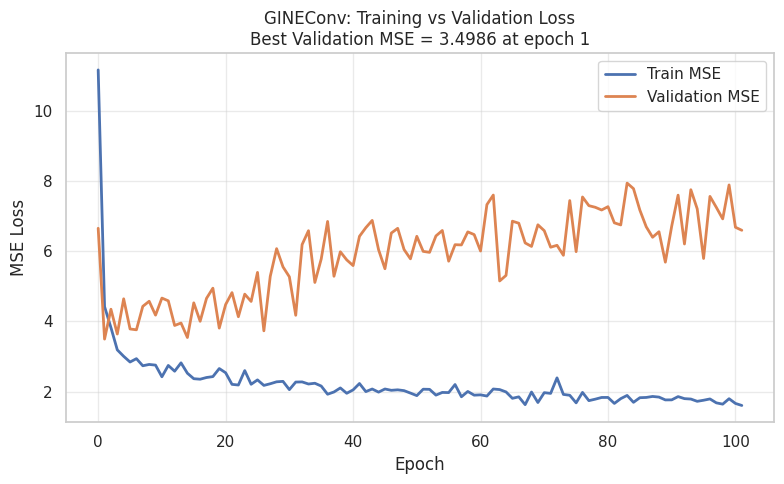

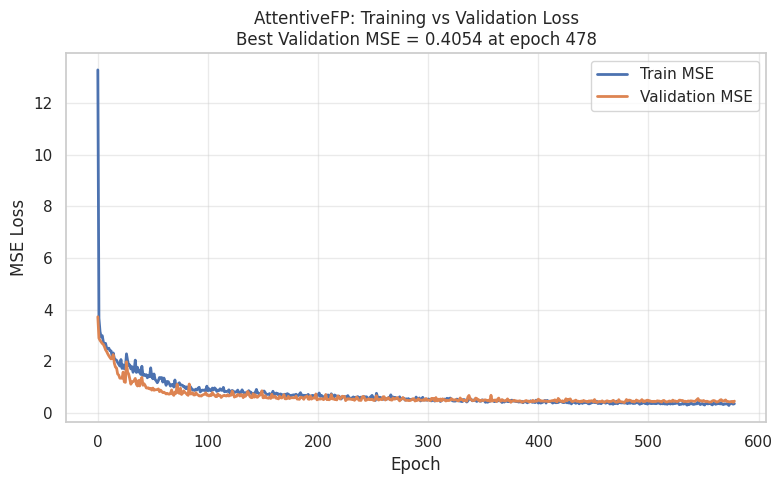

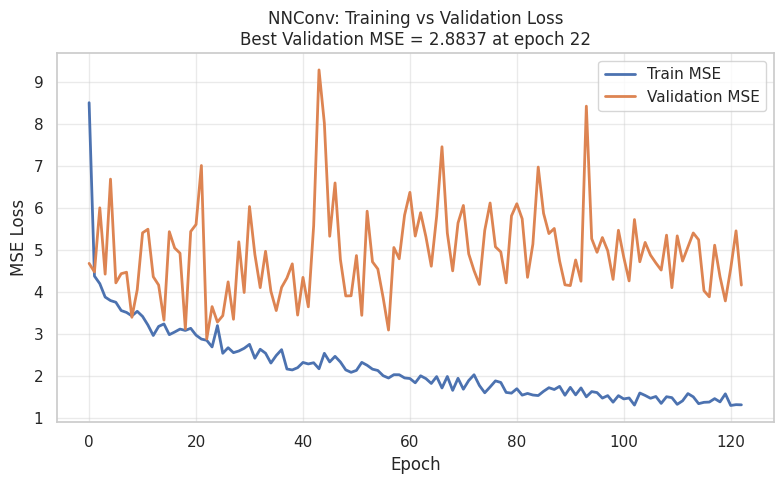

In [17]:
  %matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Build loss dataframe
# --------------------------------------------------
loss_rows = []

for model_name, result in comparison_results.items():
    for epoch, loss in enumerate(result["train_losses"]):
        loss_rows.append({
            "Model": model_name,
            "Epoch": epoch,
            "Loss Type": "Train MSE",
            "MSE Loss": loss
        })

    for epoch, loss in enumerate(result["val_losses"]):
        loss_rows.append({
            "Model": model_name,
            "Epoch": epoch,
            "Loss Type": "Validation MSE",
            "MSE Loss": loss
        })

loss_df_all = pd.DataFrame(loss_rows)

# --------------------------------------------------
# One separate figure per model
# --------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")

model_names = list(comparison_results.keys())

for model_name in model_names:
    model_df = loss_df_all[loss_df_all["Model"] == model_name]

    val_losses = comparison_results[model_name]["val_losses"]
    best_val_loss = min(val_losses)
    best_epoch = int(np.argmin(val_losses))

    plt.figure(figsize=(8, 5))

    ax = sns.lineplot(
        data=model_df,
        x="Epoch",
        y="MSE Loss",
        hue="Loss Type",
        linewidth=2
    )

    ax.set_title(
        f"{model_name}: Training vs Validation Loss\n"
        f"Best Validation MSE = {best_val_loss:.4f} at epoch {best_epoch}"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")

    plt.grid(True, alpha=0.4)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

## 18. Plot the cosine annealing learning-rate schedule

This cell visualizes the learning rate used during training.

With cosine annealing, the learning rate smoothly decreases from the initial value toward `ETA_MIN`. The idea is to allow larger updates early in training and smaller refinements later.

This plot confirms that the scheduler behaved as expected for each model.

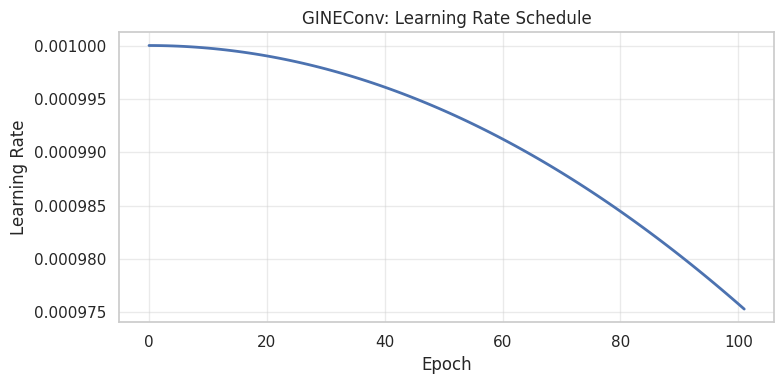

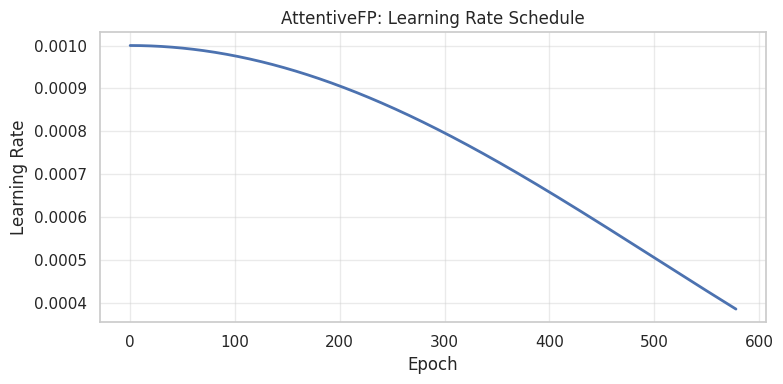

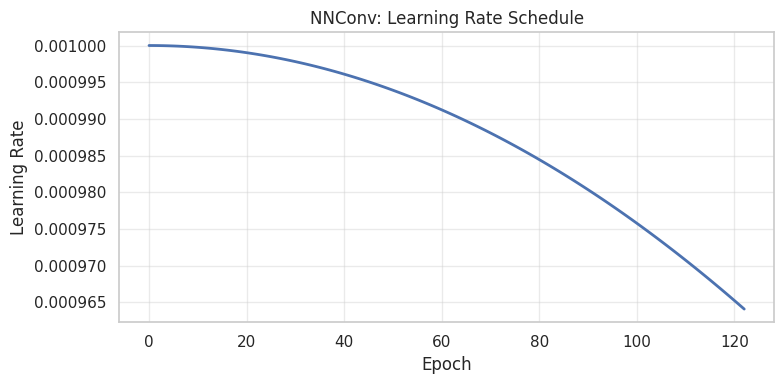

In [18]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

lr_rows = []

for model_name, result in comparison_results.items():
    for epoch, lr_value in enumerate(result["lr_history"]):
        lr_rows.append({
            "Model": model_name,
            "Epoch": epoch,
            "Learning Rate": lr_value
        })

lr_df = pd.DataFrame(lr_rows)

sns.set_theme(style="whitegrid", context="notebook")

for model_name in comparison_results.keys():
    model_df = lr_df[lr_df["Model"] == model_name]

    plt.figure(figsize=(8, 4))
    ax = sns.lineplot(
        data=model_df,
        x="Epoch",
        y="Learning Rate",
        linewidth=2
    )

    ax.set_title(f"{model_name}: Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")

    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


## 19. Compare test RMSE across architectures

This bar plot compares the final test RMSE of the three models.

RMSE is often easier to interpret than MSE because it has the same unit as the target value. For ESOL, lower test RMSE indicates better predictive accuracy on unseen molecules.

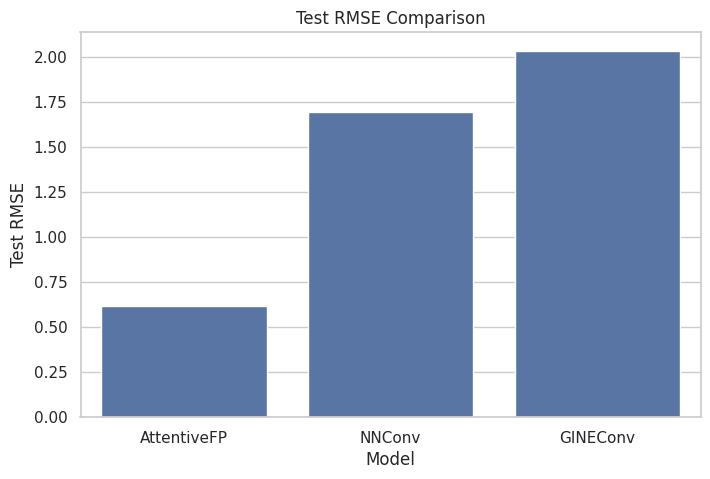

In [19]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=comparison_df,
    x="Model",
    y="Test RMSE"
)

ax.set_title("Test RMSE Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Test RMSE")

plt.grid(True, axis="y")
plt.show()


## 20. Plot predicted vs true ESOL values for every model

This cell creates a predicted-vs-true scatter plot for each architecture.

In each plot:

- the x-axis is the true ESOL value,
- the y-axis is the model prediction,
- the dashed diagonal line represents perfect prediction,
- points close to the diagonal are better predictions,
- points far from the diagonal are larger errors.

This visualization is useful because two models can have similar RMSE but behave differently across the target range. For example, one model may predict well near average solubility values but perform poorly for very high or very low solubility molecules.

Model: GINEConv
Test MSE:  4.1352
Test RMSE: 2.0335
Test MAE:  1.5557
Test R²:   0.1233


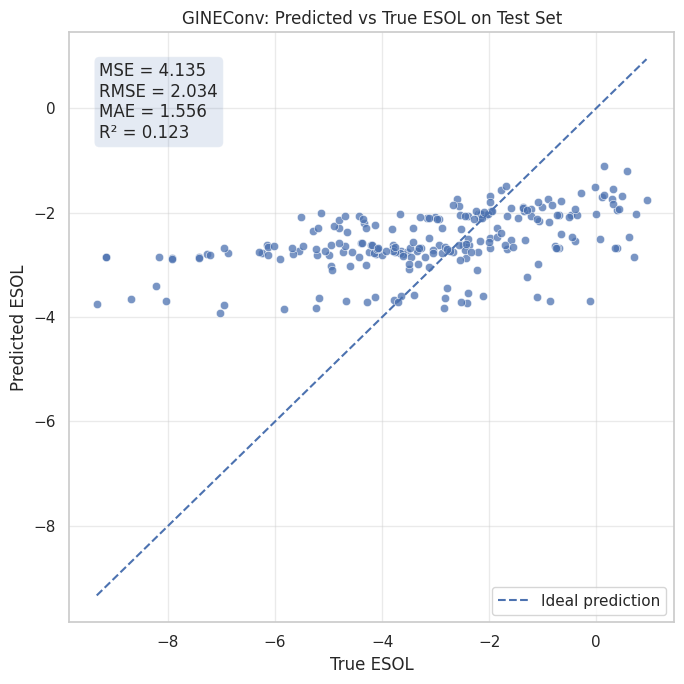

Model: AttentiveFP
Test MSE:  0.3790
Test RMSE: 0.6156
Test MAE:  0.4507
Test R²:   0.9197


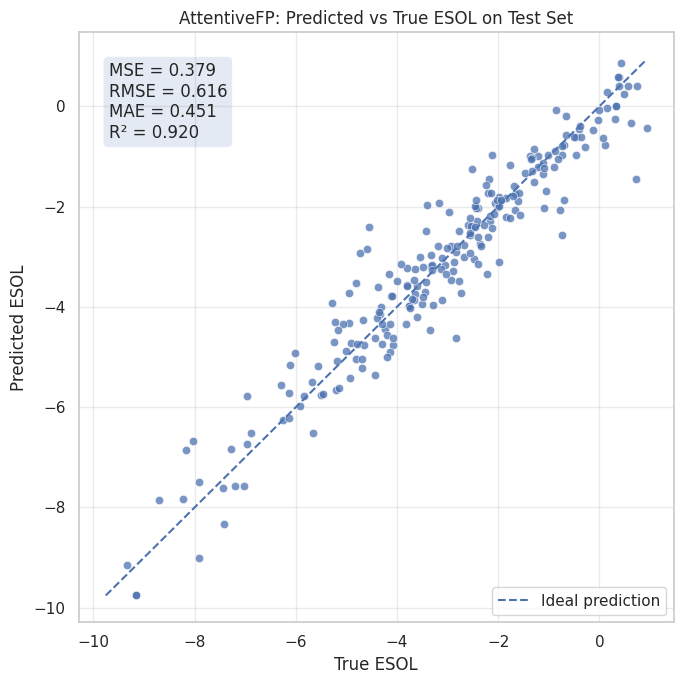

Model: NNConv
Test MSE:  2.8612
Test RMSE: 1.6915
Test MAE:  1.3297
Test R²:   0.3934


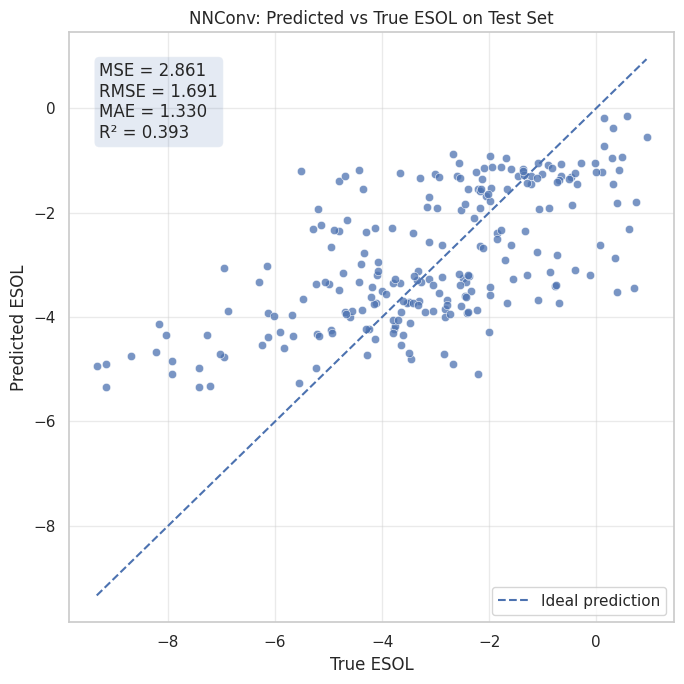

In [20]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Predicted vs true ESOL plot for each model
# --------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")

for model_name, result in comparison_results.items():
    y_true = result["y_true_test"]
    y_pred = result["y_pred_test"]
    metrics = result["test_metrics"]

    pred_df = pd.DataFrame({
        "True ESOL": y_true,
        "Predicted ESOL": y_pred,
        "Error": y_pred - y_true,
        "Absolute Error": np.abs(y_pred - y_true)
    })

    mse = metrics["MSE"]
    rmse = metrics["RMSE"]
    mae = metrics["MAE"]
    r2 = metrics["R2"]

    print("=" * 70)
    print(f"Model: {model_name}")
    print(f"Test MSE:  {mse:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test MAE:  {mae:.4f}")
    print(f"Test R²:   {r2:.4f}")

    plt.figure(figsize=(7, 7))

    ax = sns.scatterplot(
        data=pred_df,
        x="True ESOL",
        y="Predicted ESOL",
        alpha=0.75
    )

    # Ideal prediction line y = x
    min_val = min(
        pred_df["True ESOL"].min(),
        pred_df["Predicted ESOL"].min()
    )
    max_val = max(
        pred_df["True ESOL"].max(),
        pred_df["Predicted ESOL"].max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        label="Ideal prediction"
    )

    ax.set_title(f"{model_name}: Predicted vs True ESOL on Test Set")
    ax.set_xlabel("True ESOL")
    ax.set_ylabel("Predicted ESOL")

    metrics_text = (
        f"MSE = {mse:.3f}\n"
        f"RMSE = {rmse:.3f}\n"
        f"MAE = {mae:.3f}\n"
        f"R² = {r2:.3f}"
    )

    plt.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

## 21. Interpretation notes and next steps

The notebook now compares `GINEConv`, `AttentiveFP`, and `NNConv` under a consistent training and evaluation protocol.

Main conceptual differences:

| Architecture | How message passing works | How edge attributes are used |
|---|---|---|
| `GINEConv` | Aggregates transformed neighbor embeddings with a GIN-style update | Edge features are injected directly into each message-passing layer |
| `AttentiveFP` | Learns attention weights over molecular neighborhoods and graph readout steps | Edge features are used through the edge-aware part of PyG's AttentiveFP implementation |
| `NNConv` | Uses edge-conditioned filters for each bond | Edge features generate message transformation matrices |

For a small learning project, this random 60/20/20 split is acceptable and easy to understand. For a stronger molecular machine-learning benchmark, a scaffold split would be more chemically realistic because it tests whether the model generalizes to molecules with different structural scaffolds.